In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Dataset/2.titanic.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)  # 出现频率最高的值(众数)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'C':0, 'Q':1, 'S':2})

df.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True)

print(df.head())

   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0            1         0       3    0  22.0      1      0   7.2500       2.0
1            2         1       1    1  38.0      1      0  71.2833       0.0
2            3         1       3    1  26.0      0      0   7.9250       2.0
3            4         1       1    1  35.0      1      0  53.1000       2.0
4            5         0       3    0  35.0      0      0   8.0500       2.0


In [10]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
clf = DecisionTreeClassifier(random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.7262569832402235


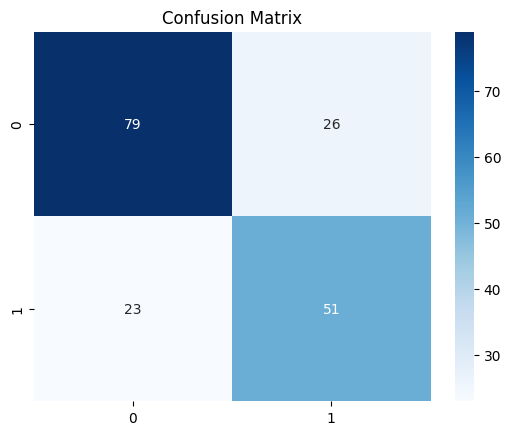

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       105
           1       0.66      0.69      0.68        74

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179



In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

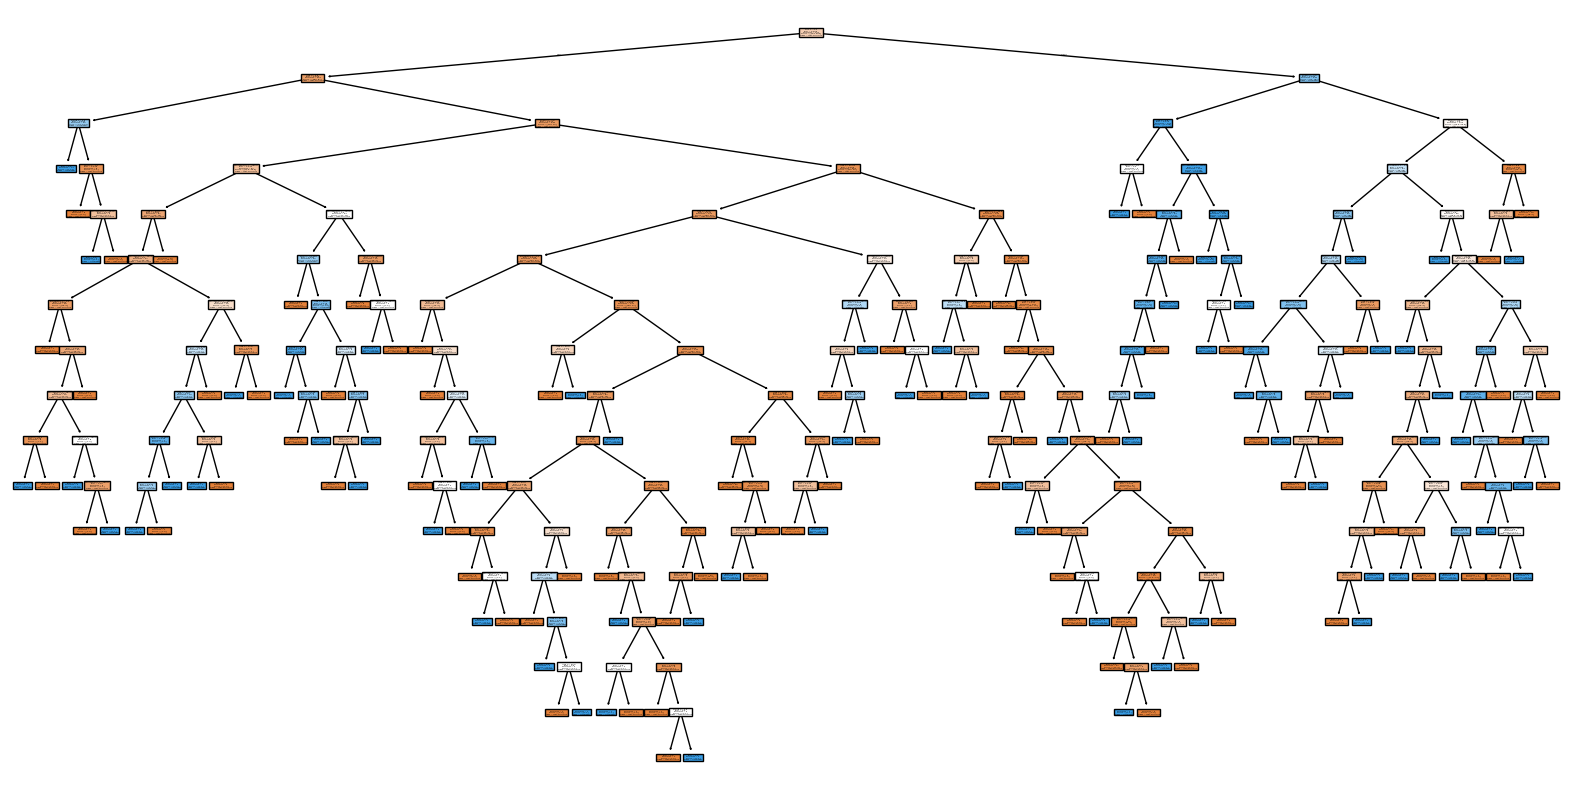

In [14]:
plt.figure(figsize=(20, 10))

plot_tree(clf, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

In [15]:
param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("best parameters:", grid_search.best_params_)

best_clf = grid_search.best_estimator_
best_clf.fit(X_train, y_train)

y_pred_optimized = best_clf.predict(X_test)

print(accuracy_score(y_test, y_pred_optimized))

Fitting 5 folds for each of 90 candidates, totalling 450 fits
best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.7988826815642458


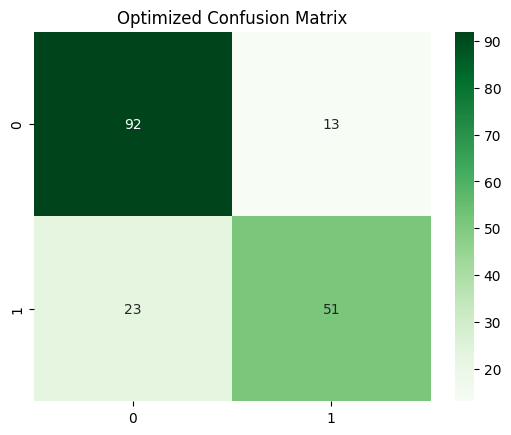

In [16]:
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm_optimized, annot=True, fmt="d", cmap="Greens")
plt.title("Optimized Confusion Matrix")
plt.show()

优化后分类报告:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



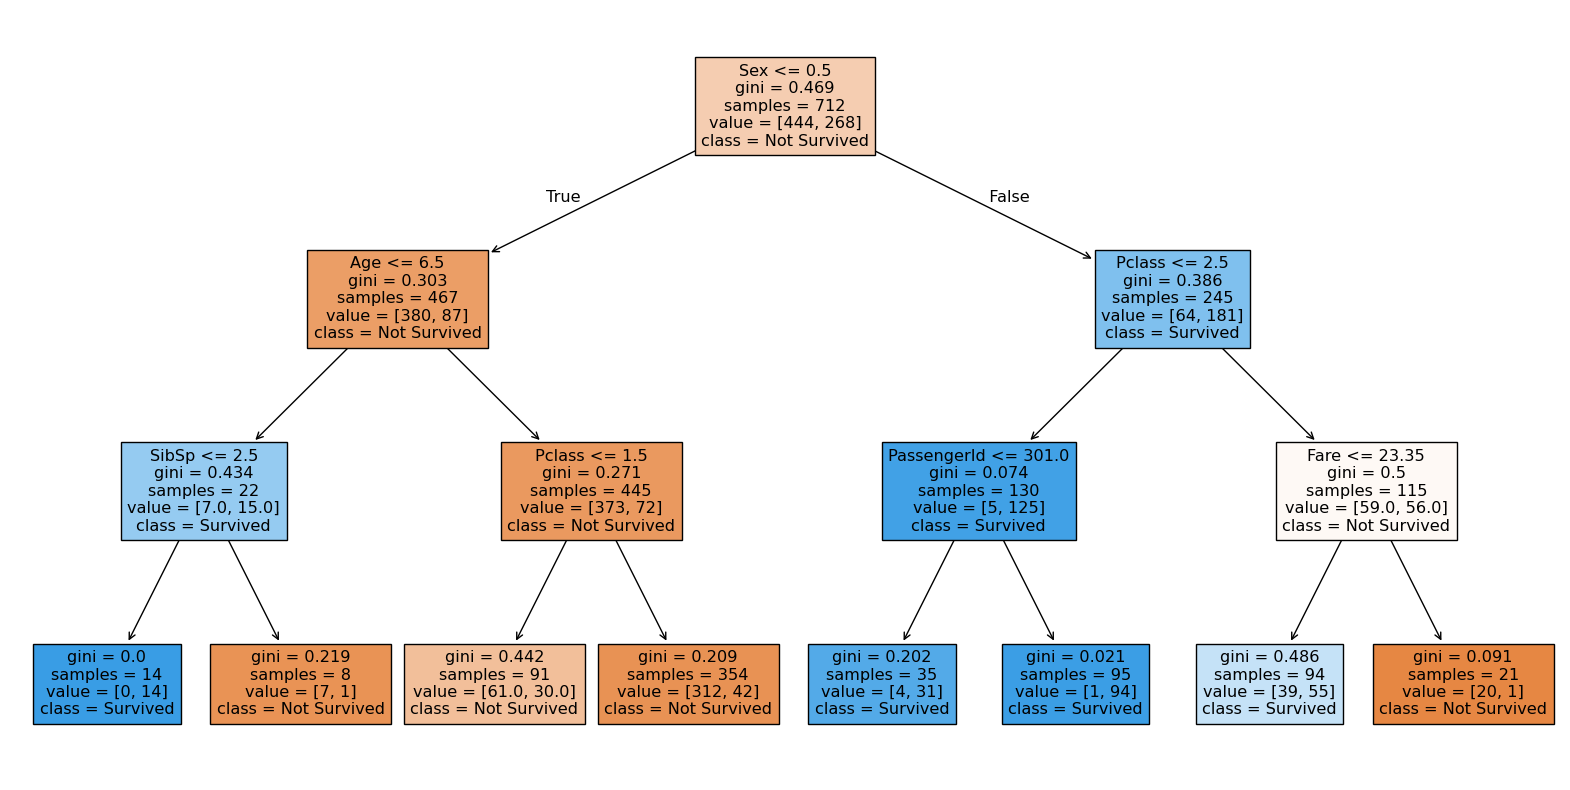

In [17]:
# 分类报告
print("优化后分类报告:")
print(classification_report(y_test, y_pred_optimized))

# 优化后决策树可视化
plt.figure(figsize=(20,10))
plot_tree(best_clf, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

决策树的适用场景和替代方案
适用场景：
1. 可解释性需求强：在一些需要可解释性的场合（如医疗诊断、金融风控），决策树模型因其直观的规则集结构，便于理解和解释。

2. 小数据集：决策树在处理中小型数据集时表现较好，训练速度快且无需大量预处理。

3. 数据类型多样：决策树能够处理混合数据类型（数值型和类别型数据），且对缺失值不敏感，因此适合处理数据类型复杂的问题。

替代方案的适用场景：
1. 需要更高的预测精度：如果预测准确率是主要目标，且对模型的可解释性要求不高，可以考虑随机森林、梯度提升树等集成学习方法。

2. 数据量大且噪音较多：在大数据集且噪音较多的情况下，决策树容易过拟合。集成方法（如随机森林、梯度提升树）可以通过多树结构降低噪声对模型的影响。

3. 非线性复杂边界：对于复杂的非线性分类问题，支持向量机或神经网络往往能提供比决策树更优的性能。